# Ablation — Axe 1 : With vs Without Precedence

**Question :** Le precedence network améliore-t-il l'apprentissage ?

Compare baseline vs precedence (meilleure config) pour DQN et PPO sur CartPole et CliffWalking.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
from ablation_utils import *


In [2]:
# False = charge les résultats déjà entraînés (rapide)
# True  = ré-entraîne DQN CartPole baseline + precedence (3 seeds, ~300 ep)
RUN_TRAINING = False
ENVS = ["CartPole-v1", "CliffWalking-v1"]
ALGOS = ["dqn", "ppo"]


In [3]:
results = {"entries": []}

for env in ENVS:
    for algo in ALGOS:
        base = load_baseline_metrics(algo, env)
        if base:
            base["env_name"] = env
            results["entries"].append(base)
            print(f"✓ baseline {algo} {env}: final={base['train_final_mean']:.1f} eval={base['eval_mean']:.1f}")
        else:
            print(f"⚠ baseline manquant: {algo} {env}")

        best_cfg = pick_best_wm_config(algo, env)
        prec = load_precedence_config(algo, env, best_cfg)
        if prec:
            prec["label"] = f"{algo.upper()}+prec (config{best_cfg})"
            results["entries"].append(prec)
            print(f"✓ precedence {algo} {env} cfg{best_cfg}: final={prec['train_final_mean']:.1f}")
        else:
            print(f"⚠ precedence manquant: {algo} {env}")

if RUN_TRAINING and "CartPole-v1" in ENVS:
    print("\nEntraînement DQN CartPole (baseline + precedence best)...")
    base_runs = run_multi_seed_cartpole(
        lambda seed, **kw: train_dqn_cartpole(seed=seed, use_precedence=False, **kw))
    prec_runs = run_multi_seed_cartpole(
        lambda seed, **kw: train_dqn_cartpole(seed=seed, use_precedence=True, wm_config=2, **kw))
    results["dqn_cartpole_baseline_trained"] = base_runs
    results["dqn_cartpole_precedence_trained"] = prec_runs


✓ baseline dqn CartPole-v1: final=327.3 eval=142.8
✓ precedence dqn CartPole-v1 cfg1: final=147.3
✓ baseline ppo CartPole-v1: final=480.0 eval=500.0
✓ precedence ppo CartPole-v1 cfg2: final=472.1
✓ baseline dqn CliffWalking-v1: final=-15.2 eval=-15.0
✓ precedence dqn CliffWalking-v1 cfg3: final=-14.1
✓ baseline ppo CliffWalking-v1: final=-4002.0 eval=-200.0
✓ precedence ppo CliffWalking-v1 cfg2: final=-13.0


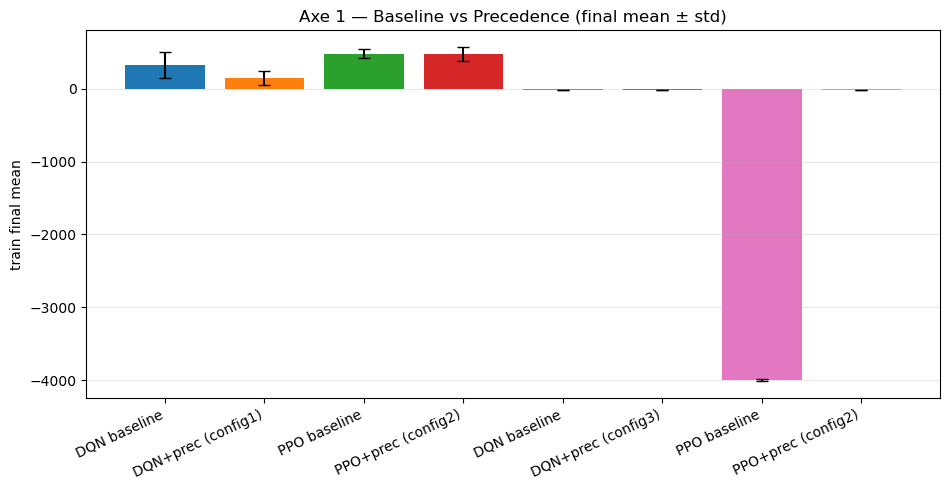

📊 /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/plots/ablation_with_vs_without_bars.png


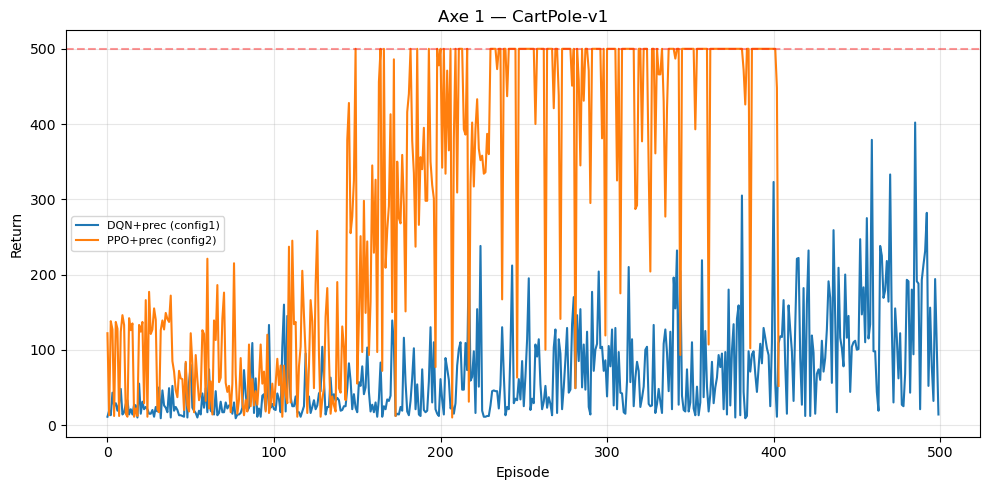

📊 /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/plots/ablation_with_vs_without_CartPole_v1.png


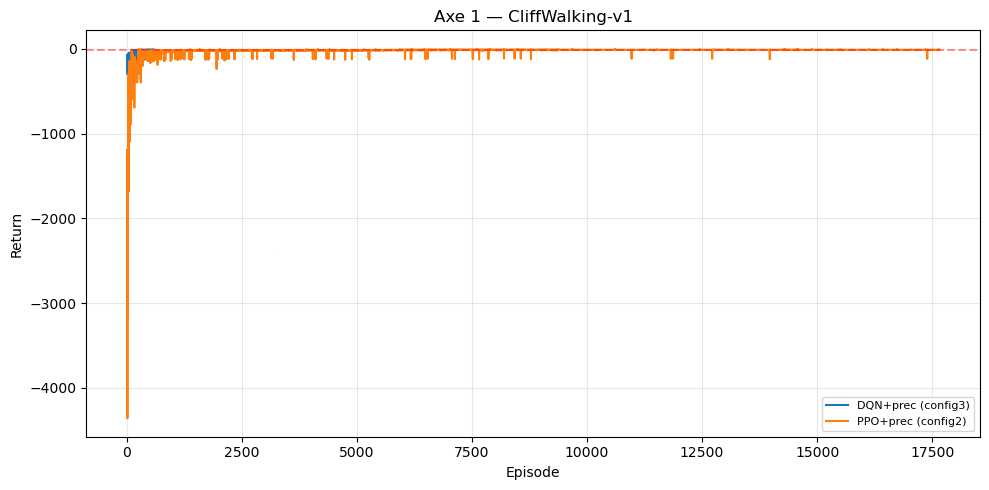

📊 /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/plots/ablation_with_vs_without_CliffWalking_v1.png
✅ Saved → /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/results/ablation_with_vs_without.json


PosixPath('/Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/results/ablation_with_vs_without.json')

In [4]:
# Bar chart — final mean (50 derniers épisodes) + eval greedy
plot_groups = {}
for e in results["entries"]:
    key = f"{e['env_name']}\n{e['label']}"
    plot_groups[key] = {"rewards": e.get("rewards", []), "train_final_mean": e["train_final_mean"]}

plot_bar_comparison(
    results["entries"],
    title="Axe 1 — Baseline vs Precedence (final mean ± std)",
    save_name="ablation_with_vs_without_bars.png",
)

for env in ENVS:
    subset = [e for e in results["entries"] if e["env_name"] == env]
    curves = {e["label"]: {"rewards": e.get("rewards", []), "reward_curves": [e.get("rewards", [])]} for e in subset if e.get("rewards")}
    if curves:
        plot_learning_curves(curves, f"Axe 1 — {env}", f"ablation_with_vs_without_{env.replace('-','_')}.png",
                             solve_threshold=ENV_SPECS[env]["solve_threshold"])

save_ablation_result("ablation_with_vs_without", results)
